## In 2017, Nice Ride Minnesota recorded 460,718 bike trips across 202 stations. However, bike demand may not be evenly distributed across different times and stations. 


## import the data and check all data test 

In [54]:
import pandas as pd 
import matplotlib.ticker as ticker

In [2]:
station = pd.read_csv('Nice_Ride_2017_Station_Locations.csv')
session = pd.read_csv('Nice_ride_trip_history_2017_season.csv')
weather = pd.read_csv('WeatherDailyMinneapolis2017.csv')

C:\Users\Walmu\AppData\Local\Temp\ipykernel_17516\2971259171.py:2: DtypeWarning: Columns (2,5) have mixed types. Specify dtype option on import or set low_memory=False.
  session = pd.read_csv('Nice_ride_trip_history_2017_season.csv')


In [3]:
station.head()

,Number,Name,Latitude,Longitude,Total docks
0,30000,100 Main Street SE,44.984892,-93.256551,27
1,30001,25th Street & 33rd Ave S,44.957341,-93.223374,15
2,30002,Riverside Ave & 23rd Ave S,44.967115,-93.240149,15
3,30003,Plymouth Ave N & N Oliver Ave,44.991412,-93.306269,15
4,30004,11th Street & Hennepin,44.975340,-93.278690,23


In [4]:
session.head()

,Start date,Start station,Start station number,End date,End station,End station number,Account type,Total duration (Seconds)
0,11/5/2017 21:45,Hennepin Ave & S Washington Ave,30184,11/5/2017 22:02,Logan Park,30104,Member,1048
1,11/5/2017 21:45,Broadway Street N & 4th Street E,30122,11/5/2017 22:26,Broadway Street N & 4th Street E,30122,Member,2513
2,11/5/2017 21:43,Dale Street & Grand Ave.,30106,11/5/2017 22:13,N Milton Street & Summit Ave,30101,Member,1817
3,11/5/2017 21:41,Weisman Art Museum,30183,11/5/2017 22:05,22nd Ave S & Franklin Ave,30014,Casual,1399
4,11/5/2017 21:38,South 2nd Street & 3rd Ave S,30030,11/5/2017 21:44,6th Ave SE & University Ave,30088,Member,370


In [5]:
weather.head()

,STATION,NAME,DATE,PRCP,TMAX,TMIN
0,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-01,0.00,26,18
1,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-02,0.00,31,20
2,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-03,0.01,30,25
3,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-04,0.00,25,-6
4,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-05,0.01,2,-8


In [6]:
print(station.shape)
print(session.shape)
print(weather.shape)

(202, 5)
(460718, 8)
(365, 6)


In [7]:
station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Number       202 non-null    object 
 1   Name         202 non-null    object 
 2   Latitude     202 non-null    float64
 3   Longitude    202 non-null    float64
 4   Total docks  202 non-null    int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 8.0+ KB


In [8]:
## number here is object we should convert it :

In [9]:
session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460718 entries, 0 to 460717
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Start date                460718 non-null  object
 1   Start station             460718 non-null  object
 2   Start station number      460718 non-null  object
 3   End date                  460718 non-null  object
 4   End station               460718 non-null  object
 5   End station number        460718 non-null  object
 6   Account type              460718 non-null  object
 7   Total duration (Seconds)  460718 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 28.1+ MB


In [10]:
## Date here is object we should convert it :
session["Start date"] = pd.to_datetime(session["Start date"])
session["End date"] = pd.to_datetime(session["End date"])

In [11]:
session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460718 entries, 0 to 460717
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Start date                460718 non-null  datetime64[ns]
 1   Start station             460718 non-null  object        
 2   Start station number      460718 non-null  object        
 3   End date                  460718 non-null  datetime64[ns]
 4   End station               460718 non-null  object        
 5   End station number        460718 non-null  object        
 6   Account type              460718 non-null  object        
 7   Total duration (Seconds)  460718 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(5)
memory usage: 28.1+ MB


In [12]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  365 non-null    object 
 1   NAME     365 non-null    object 
 2   DATE     365 non-null    object 
 3   PRCP     365 non-null    float64
 4   TMAX     365 non-null    int64  
 5   TMIN     365 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 17.2+ KB


In [13]:
## Date here is object we should convert it :
weather["DATE"] = pd.to_datetime(weather["DATE"])

In [14]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  365 non-null    object        
 1   NAME     365 non-null    object        
 2   DATE     365 non-null    datetime64[ns]
 3   PRCP     365 non-null    float64       
 4   TMAX     365 non-null    int64         
 5   TMIN     365 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 17.2+ KB


In [15]:
weather

,STATION,NAME,DATE,PRCP,TMAX,TMIN
0,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-01,0.00,26,18
1,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-02,0.00,31,20
2,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-03,0.01,30,25
3,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-04,0.00,25,-6
4,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-01-05,0.01,2,-8
...,...,...,...,...,...,...
360,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-12-27,0.00,-2,-11
361,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-12-28,0.05,4,-10
362,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-12-29,0.01,10,-4
363,USC00218450,"UNIVERSITY OF MN ST. PAUL, MN US",2017-12-30,0.01,0,-16


In [16]:
weather['TMAX'].unique() # to make shure the tempreture is f or c 

array([26, 31, 30, 25,  2,  0,  5,  7, 17,  8, 12, 22, 32, 34, 40, 37, 35,
       36, 38, 33, 28, 27, 29, 39, 16, 24, 19, 44, 43, 45, 61, 57, 56, 53,
       20, 42, 52, 41, 48, 46, 54, 63, 49, 59, 58, 69, 70, 50, 62, 60, 67,
       66, 64, 77, 65, 75, 80, 83, 81, 72, 73, 79, 88, 89, 87, 84, 86, 93,
       82, 71, 74, 78, 85, 90, 91, 68, 76, 51, 55, 21, 18, -2,  4, 10, -8])

In [17]:
station.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
197    False
198    False
199    False
200    False
201    False
Length: 202, dtype: bool

In [18]:
session.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
460713    False
460714    False
460715    False
460716    False
460717    False
Length: 460718, dtype: bool

In [19]:
weather.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
360    False
361    False
362    False
363    False
364    False
Length: 365, dtype: bool

#### all pravoius  3 datas no have missing value or duplicated value and is normal  then i can to approchs 


# approch 

## 1-How does bike demand vary by month, day, and hour?

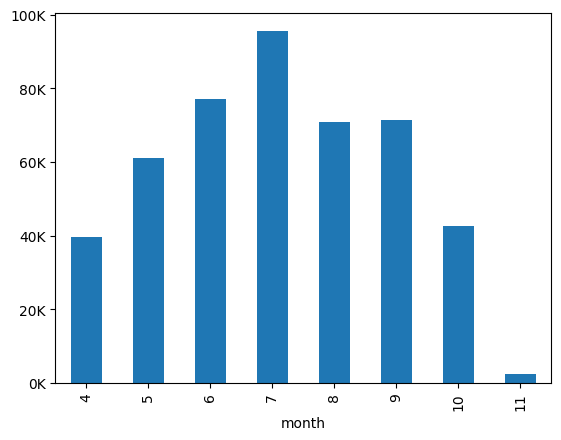

In [57]:
session["month"] = session["Start date"].dt.month
session["day"] = session["Start date"].dt.day_name()
session["hour"] = session["Start date"].dt.hour
y=session.groupby("month").size().plot(kind="bar")
y.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y/1000:g}K"))

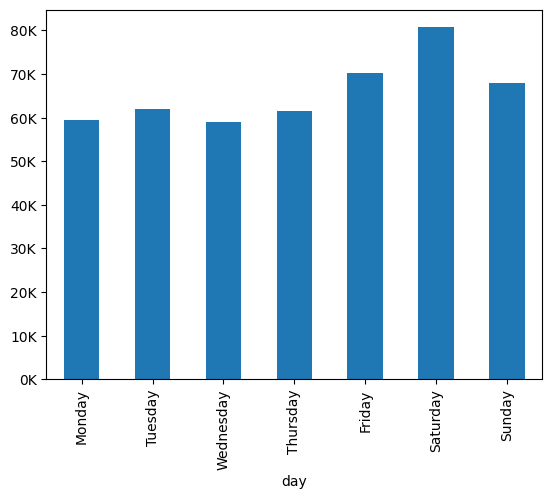

In [81]:
x = session.groupby("day").size().reindex(["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday", "Sunday"]).plot(kind="bar")
x.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1000:g}K"))

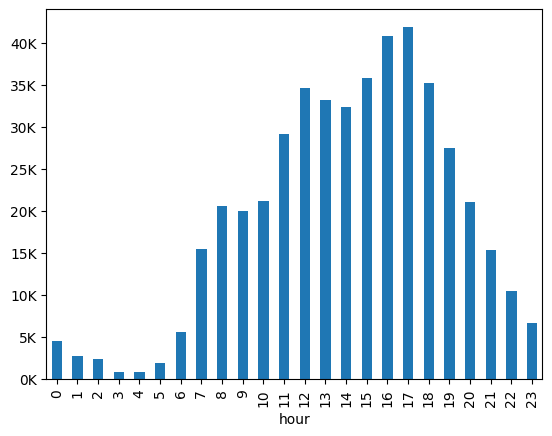

In [63]:
y=session.groupby("hour").size().plot(kind="bar")
y.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y/1000:g}K"))

## 2-Which stations have the highest and lowest bike demand?

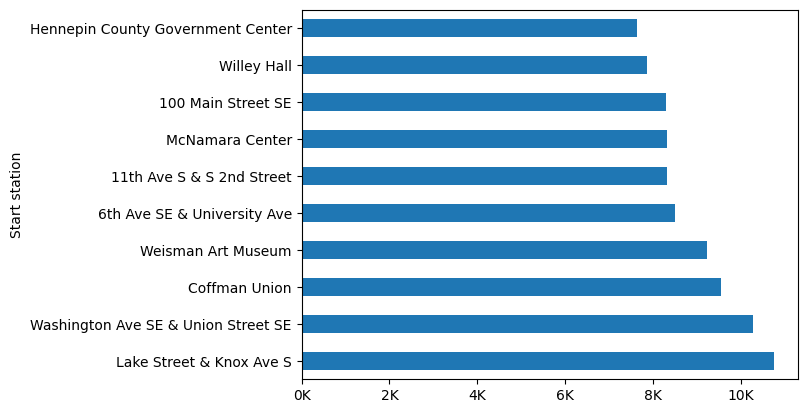

In [56]:
station_demand = session["Start station"].value_counts()
x=station_demand.head(10).plot(kind="barh")
x = station_demand.head(10).plot(kind="barh")
x.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1000:g}K"))

<Axes: ylabel='Start station'>

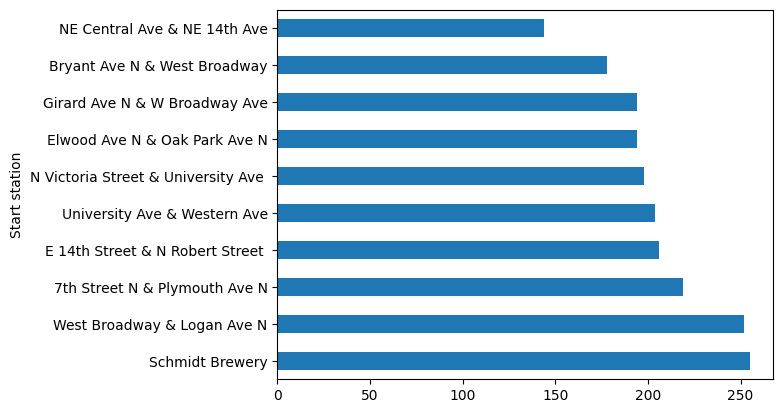

In [24]:
station_demand.tail(10).plot(kind="barh")

### 3-How does weather affect daily bike demand?

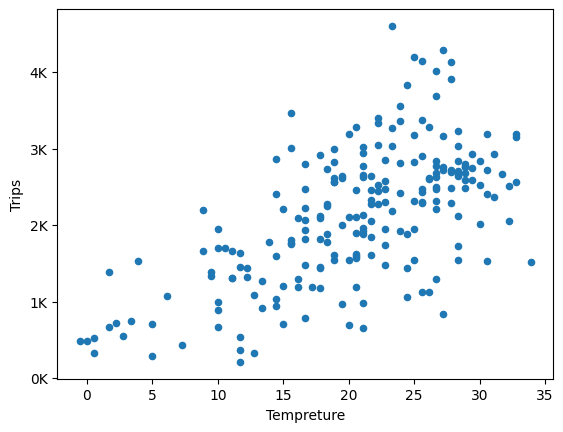

In [64]:
session["date"] = session["Start date"].dt.date
weather["date"] = weather["DATE"].dt.date
weather["Tempreture"] = (weather["TMAX"] - 32) * 5/9
daily_trips = session.groupby("date").size()
weather["Trips"] = weather["date"].map(daily_trips)
y=weather.plot(x="Tempreture",y="Trips",kind="scatter")
y.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y/1000:g}K"))

## 4- Do members and casual users use bikes differently?

<Axes: xlabel='Average Trip Duration (Minutes)', ylabel='Account type'>

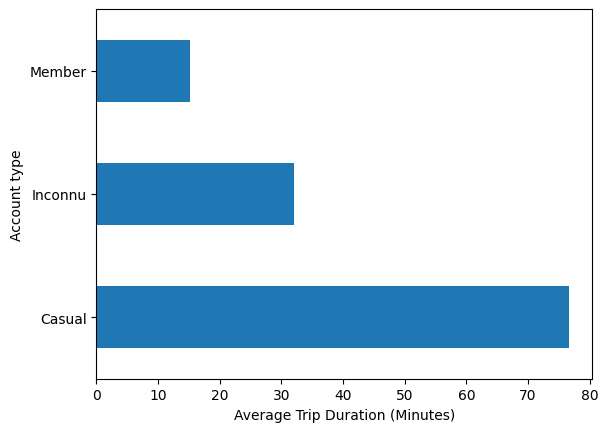

In [47]:
session["duration_minutes"] = session["Total duration (Seconds)"] / 60
session.groupby("Account type")["duration_minutes"].mean().plot( kind="barh", xlabel="Average Trip Duration (Minutes)")

## 5- Are bike trips longer on weekends or weekdays?

<Axes: ylabel='Average Trip Duration (%)'>

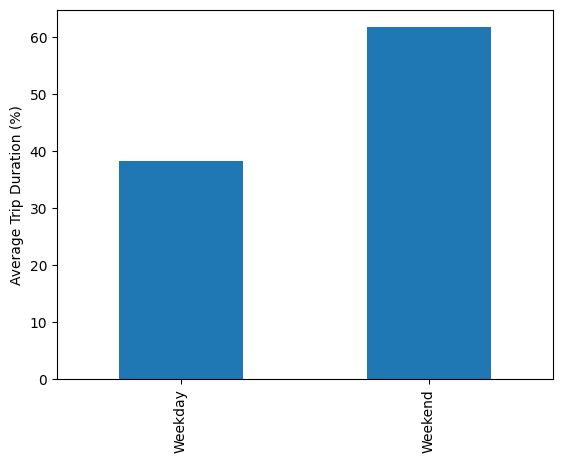

In [43]:
session["duration_minutes"] = session["Total duration (Seconds)"] / 60
session["day_type"] = session["Start date"].dt.dayofweek
session["day_type"] = session["day_type"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")
avg_time = session.groupby("day_type")["duration_hours"].mean()
percentage = avg_time / avg_time.sum() * 100
percentage.plot(kind="bar",xlabel="",ylabel="Average Trip Duration (%)")

## 6- Which stations are most commonly used as both start and end stations?

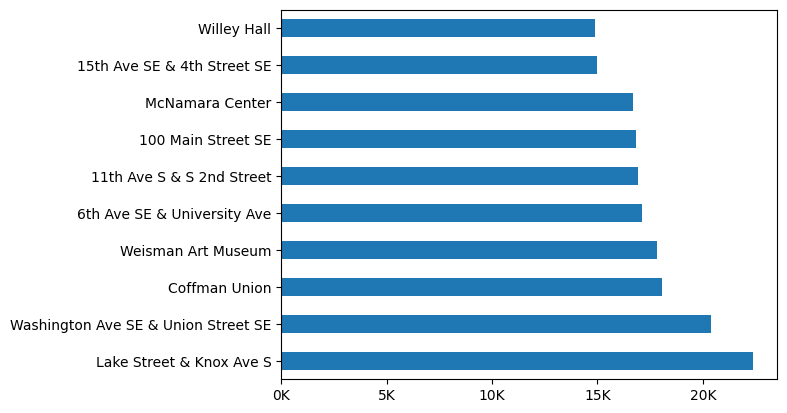

In [76]:
start = session["Start station"].value_counts()
end = session["End station"].value_counts()
station["total_trips"] = station["Name"].map(start) + station["Name"].map(end)
y=station.sort_values("total_trips", ascending=False).head(10).plot(x="Name",y="total_trips",kind="barh",xlabel="",ylabel="",legend=False)
y.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1000:g}K"))
